In [1]:
import numpy as np
import cupy as cp
import cupyx.scipy.sparse as sp
from cupyx.scipy.sparse.linalg import gmres
from scipy.sparse.linalg import cg
import pandas as pd
import matplotlib.pyplot as plt
from pySDC.playgrounds.mixed_precision.paths import ensure_output_dirs, image_path, table_path
from pySDC.playgrounds.mixed_precision.gmres_counter import gmres_with_count
import scipy.sparse as scp
np.set_printoptions(linewidth=300, precision=3)

from qmat import QDELTA_GENERATORS

from pySDC.core.collocation import CollBase
from pySDC.implementations.problem_classes.HeatEquation_ND_FD import heatNd_unforced
from pySDC.implementations.problem_classes.AllenCahn_2D_FD import allencahn_fullyimplicit
from pySDC.implementations.problem_classes.GeneralizedFisher_1D_FD_implicit import generalized_fisher
from pySDC.implementations.problem_classes.Auzinger_implicit import auzinger

class counter(object):
    def __init__(self, disp=False):
        self._disp = disp
        self.niter = 0
    def __call__(self, rk=None):
        self.niter += 1
        if self._disp:
            # print('iter %3i\trk = %s' % (self.niter, str(rk)))
            print('   LIN: %3i' % self.niter)
    def get_iter(self):
        return self.niter

ensure_output_dirs()

In [18]:
def nonlinear_sdc_cahn(dt = 0.0005, num_nodes = 4, nvars = (64, 64), nu = 2, eps=0.04, const_inner_iteration = False,
                  outer_abs_tol = 1E-14, inner_abs_tol = 1E-14, rel_tol = 1E-12, k_max = 10_000, n_max = 10_000):
    # instantiate problem
    prob = allencahn_fullyimplicit(nvars=nvars, nu = nu, eps = eps)

    coll = CollBase(num_nodes=num_nodes, tleft=0, tright=1, node_type='LEGENDRE', quad_type='RADAU-RIGHT')

    generator = QDELTA_GENERATORS['MIN-SR-S'](
        # for algebraic types (LU, ...)
        Q=coll.generator.Q,
        # for MIN in tables, MIN-SR-S ...
        nNodes=coll.num_nodes,
        nodeType=coll.node_type,
        quadType=coll.quad_type,
        # for time-stepping types, MIN-SR-NS
        nodes=coll.nodes,
        tLeft=coll.tleft,
    )
    QDmat = cp.asarray(generator.genCoeffs(k=None))

    # shrink collocation matrix: first line and column deals with initial value, not needed here
    Q = cp.asarray(coll.Qmat[1:, 1:])

    u0 = cp.asarray(prob.u_exact(t=0).flatten())
    # fill in u0-vector as right-hand side for the collocation problem
    u0_coll = cp.kron(cp.ones(coll.num_nodes), u0)

    nvars = prob.nvars[0] * prob.nvars[1]

    uk = cp.zeros(nvars * coll.num_nodes, dtype='float64')
    fk = cp.zeros(nvars * coll.num_nodes, dtype='float64')

    ksum = 0
    nsum = 0
    gmres_sum = 0
    timepoints = cp.arange(0, 0.01+dt, step=dt)
    u_buffer = cp.empty((len(timepoints), nvars))
    conv_buffer = cp.zeros(len(timepoints)) # marks the iteration, reaching the desired tolerances
    conv_buffer[0] = 1
    u_buffer[0, :] = u0

    for index, timepoint in enumerate(timepoints[:-1]):
        k = 0
        while k < k_max:
            # eval rhs
            for m in range(coll.num_nodes):
                fk[m * nvars: (m + 1) * nvars] = cp.asarray(prob.eval_f(uk[m * nvars: (m + 1) * nvars].get(),
                                                             t=timepoint + dt * coll.nodes[m]).flatten())

            resnorm = cp.linalg.norm(u0_coll - (uk - dt * sp.kron(Q, sp.eye(nvars)).dot(fk)), cp.inf)
            if resnorm < outer_abs_tol and resnorm/cp.linalg.norm(u0_coll, cp.inf) < rel_tol:
                conv_buffer[index+1] = 1
                break

            g = cp.zeros(nvars * coll.num_nodes, dtype='float64')
            vn = uk.copy()
            fn = cp.zeros(nvars * coll.num_nodes, dtype='float64')
            n = 0
            while n < n_max:
                for m in range(coll.num_nodes):
                    fn[m * nvars: (m + 1) * nvars] = cp.asarray(prob.eval_f(vn[m * nvars: (m + 1) * nvars].get(),
                                                                 t=timepoint + dt * coll.nodes[m]).flatten())
                g[:] = u0_coll + dt * sp.kron(Q-QDmat, sp.eye(nvars)).dot(fk) - (vn - dt * sp.kron(QDmat, sp.eye(nvars)).dot(fn))

                res_newton = cp.linalg.norm(g, cp.inf)
                n += 1
                nsum += 1
                if res_newton < inner_abs_tol and not const_inner_iteration:
                    break

                dg = -sp.eye(nvars * coll.num_nodes) + dt * sp.kron(QDmat, sp.eye(nvars)).dot(
                    sp.kron(sp.eye(coll.num_nodes), prob.A)
                    + 1.0 / prob.eps**2 * sp.diags((1.0 - (prob.nu + 1) * vn ** prob.nu), offsets=0)
                )

                correction, _, gmres_iter = gmres_with_count(
                    dg,
                    g,
                    x0=cp.zeros_like(vn),
                    maxiter=1000,
                    atol=inner_abs_tol,
                )
                gmres_sum += gmres_iter
                vn -= correction

            uk = vn.copy()

            k += 1
            ksum += 1
        temp = uk[-nvars:]
        u_buffer[index+1, :] = temp
        u0_coll = cp.kron(cp.ones(coll.num_nodes), temp).flatten()

    return u_buffer, timepoints, prob, ksum, nsum, gmres_sum, conv_buffer

In [17]:
%%time
u1, t1, prob, ksum, nsum, gmres_sum, conv_buffer = nonlinear_sdc_cahn(dt=0.001, num_nodes = 4, nvars=(64, 64), inner_abs_tol=1E-14, outer_abs_tol=1E-14, const_inner_iteration=True, n_max=1)
print((ksum, nsum, gmres_sum))
cp.linalg.norm(u1[-1]-cp.asarray(prob.u_exact(t1[-1]).flatten()), np.inf)

SDC: 0 0 0.999999808431071
  Newton: 0 0.999999808431071
SDC: 1 1 0.5810202013036644
  Newton: 0 0.5810202013036644
SDC: 2 2 0.0363744518869098
  Newton: 0 0.0363744518869098
SDC: 3 3 0.005428262662844907
  Newton: 0 0.005428262662845018
SDC: 4 4 0.0009712742366801974
  Newton: 0 0.0009712742366803084
SDC: 5 5 0.0001796658215817981
  Newton: 0 0.0001796658215817981
SDC: 6 6 3.6635194380574276e-05
  Newton: 0 3.6635194380574276e-05
SDC: 7 7 9.145559912770995e-06
  Newton: 0 9.145559912770995e-06
SDC: 8 8 2.1467584979117937e-06
  Newton: 0 2.1467584979117937e-06
SDC: 9 9 4.827658694472881e-07
  Newton: 0 4.827658695027992e-07
SDC: 10 10 1.0522087845465933e-07
  Newton: 0 1.0522087845465933e-07
SDC: 11 11 2.2539534794141503e-08
  Newton: 0 2.2539534905163805e-08
SDC: 12 12 4.747139459304606e-09
  Newton: 0 4.747139570326908e-09
SDC: 13 13 9.921499177778514e-10
  Newton: 0 9.921499177778514e-10
SDC: 14 14 2.0894785901504065e-10
  Newton: 0 2.0894785901504065e-10
SDC: 15 15 4.47641923528863

array(7.54140361e-10)

In [21]:
dts_allen = 1/cp.logspace(3, 4, num=4)
print(dts_allen)
norms_allen = cp.empty(len(dts_allen))

for index, dt in enumerate(dts_allen):
    print("loop index: " + str(dt))
    u, t, prob, ksum, nsum, gmres_sum, conv_buffer = nonlinear_sdc_cahn(dt = float(dt), num_nodes = 4, outer_abs_tol=1E-14, inner_abs_tol=1E-14)
    u_exact_allen =cp.asarray(prob.u_exact(t[-1]))
    norms_allen[index] = cp.max(cp.abs(u[-1] - u_exact_allen.flatten()))

[0.001      0.00046416 0.00021544 0.0001    ]
loop index: 0.001
loop index: 0.0004641588833612778
loop index: 0.00021544346900318845
loop index: 0.0001


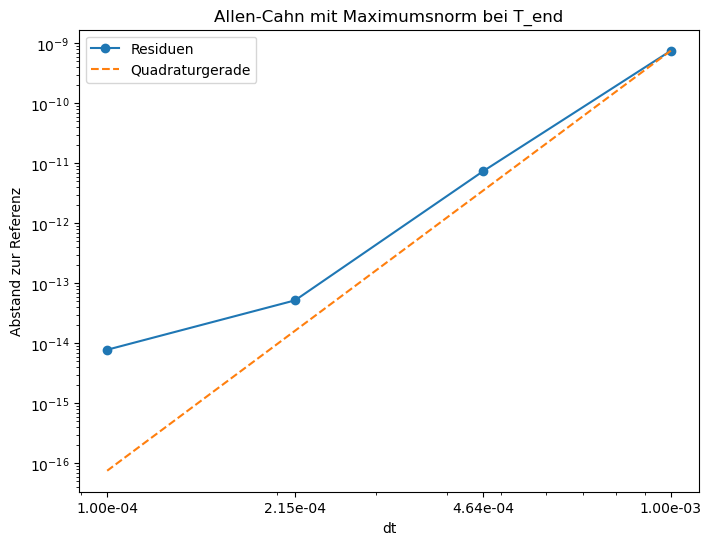

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
conv_line = cp.power(dts_allen, 7) * norms_allen[0]/np.power(dts_allen[0], 7)
ax.plot(dts_allen.get(), norms_allen.get(), marker = "o", label="Residuen")
ax.plot(dts_allen.get(), conv_line.get(), linestyle="dashed", label="Quadraturgerade")
ax.set_xscale("log", base = 10)
ax.set_xticks(dts_allen.get(), labels=["{:.2e}".format(dt) for dt in dts_allen.get()])
ax.set_yscale("log", base = 10)
#ax.set_ylim(1E-16, 1E-4)
plt.xlabel("dt")
plt.ylabel("Abstand zur Referenz")
plt.legend()
ax.set_title("Allen-Cahn mit Maximumsnorm bei T_end")
plt.savefig(image_path("allencahn_maximumsnorm.png"))

# Newton-SDC

In [19]:
def nonlinear_cahn(dt = 0.0005, num_nodes = 4, nvars = (64, 64), nu = 2, eps=0.04, const_inner_iteration = False,
                  outer_abs_tol = 1E-14, inner_abs_tol = 1E-14, rel_tol = 1E-12, k_max = 10_000, n_max = 10_000):
    # instantiate problem
    prob = allencahn_fullyimplicit(nvars=nvars, nu = nu, eps = eps)

    coll = CollBase(num_nodes=num_nodes, tleft=0, tright=1, node_type='LEGENDRE', quad_type='RADAU-RIGHT')

    generator = QDELTA_GENERATORS['MIN-SR-S'](
        # for algebraic types (LU, ...)
        Q=coll.generator.Q,
        # for MIN in tables, MIN-SR-S ...
        nNodes=coll.num_nodes,
        nodeType=coll.node_type,
        quadType=coll.quad_type,
        # for time-stepping types, MIN-SR-NS
        nodes=coll.nodes,
        tLeft=coll.tleft,
    )
    QDmat = cp.asarray(generator.genCoeffs(k=None))

    # shrink collocation matrix: first line and column deals with initial value, not needed here
    Q = cp.asarray(coll.Qmat[1:, 1:])

    u0 = cp.asarray(prob.u_exact(t=0).flatten())
    # fill in u0-vector as right-hand side for the collocation problem
    u0_coll = cp.kron(cp.ones(coll.num_nodes), u0)

    nvars = prob.nvars[0] * prob.nvars[1]

    un = cp.zeros(nvars * coll.num_nodes, dtype='float64')
    fn = cp.zeros(nvars * coll.num_nodes, dtype='float64')
    g = cp.zeros(nvars * coll.num_nodes, dtype='float64')

    ksum = 0
    nsum = 0
    gmres_sum = 0
    timepoints = cp.arange(0, 0.01+dt, step=dt)
    u_buffer = cp.empty((len(timepoints), nvars))
    u_buffer[0, :] = u0

    for index, timepoint in enumerate(timepoints[:-1]):
        n = 0
        while n < n_max:
            # form the function g with g(u) = 0
            for m in range(coll.num_nodes):
                fn[m * nvars: (m + 1) * nvars] = cp.asarray(prob.eval_f(un[m * nvars: (m + 1) * nvars].get(),
                                                             t=timepoint + dt * coll.nodes[m]).flatten())
            g[:] = u0_coll - (un - dt * sp.kron(Q, sp.eye(nvars)).dot(fn))

            res_newton = cp.linalg.norm(g, cp.inf)
            if res_newton < outer_abs_tol:
                break

            dg = -sp.eye(nvars * coll.num_nodes) + dt * sp.kron(Q, sp.eye(nvars)).dot(
                sp.kron(sp.eye(coll.num_nodes), prob.A)
                + 1.0 / prob.eps**2 * sp.diags((1.0 - (prob.nu + 1) * un ** prob.nu), offsets=0)
            )

            dgP = -sp.eye(nvars * coll.num_nodes) + dt * sp.kron(QDmat, sp.eye(nvars)).dot(
                sp.kron(sp.eye(coll.num_nodes), prob.A)
                + 1.0 / prob.eps**2 * sp.diags((1.0 - (prob.nu + 1) * un ** prob.nu), offsets=0)
            )

            vk = cp.zeros(nvars * coll.num_nodes, dtype='float64')
            res = cp.zeros(nvars * coll.num_nodes, dtype='float64')

            res[:] = g - dg.dot(vk)
            k = 0
            while k < k_max:
                correction, _, gmres_iter = gmres_with_count(
                    dgP,
                    res,
                    x0=cp.zeros_like(res),
                    maxiter=1000,
                    atol=inner_abs_tol,
                )
                gmres_sum += gmres_iter
                vk += correction

                res[:] = g - dg.dot(vk)
                resnorm = cp.linalg.norm(res, cp.inf)

                k += 1
                ksum += 1
                if resnorm < inner_abs_tol and not const_inner_iteration:
                    break

            # Update
            un -= vk

            # increase Newton iteration count
            n += 1
            nsum += 1
        temp = un[-nvars:]
        u_buffer[index+1, :] = temp
        u0_coll = cp.kron(cp.ones(coll.num_nodes), temp).flatten()

    return u_buffer, timepoints, prob, ksum, nsum, gmres_sum

In [13]:
res_c, time_c, prob_c, ksum, nsum, gmres_sum = nonlinear_cahn(dt=0.0001, num_nodes=4, outer_abs_tol=1E-14, inner_abs_tol=1E-14, const_inner_iteration=True, k_max=1)
print((ksum, nsum, gmres_sum))
cp.linalg.norm(res_c[-1]-cp.asarray(prob_c.u_exact(time_c[-1]).flatten()), cp.inf)

Newton: 0 0.999999808431071
   SDC: 0 0 0 0.038669228406282063
Newton: 1 0.026524796846375875
   SDC: 1 0 1 0.0004998073700357118
Newton: 2 0.00045579191102351757
   SDC: 2 0 2 5.7428244222635706e-06
Newton: 3 5.7363759994322194e-06
   SDC: 3 0 3 1.3650611878355952e-07
Newton: 4 1.365057125113367e-07
   SDC: 4 0 4 1.2102951990809226e-07
Newton: 5 1.2102952051673554e-07
   SDC: 5 0 5 4.055654185791408e-08
Newton: 6 4.055654190260327e-08
   SDC: 6 0 6 1.1141979038203255e-08
Newton: 7 1.1141979006090708e-08
   SDC: 7 0 7 2.821462382694051e-09
Newton: 8 2.8214623970512775e-09
   SDC: 8 0 8 6.852036272907741e-10
Newton: 9 6.852036715798704e-10
   SDC: 9 0 9 1.624455563309629e-10
Newton: 10 1.6244561251710365e-10
   SDC: 10 0 10 3.794297549163094e-11
Newton: 11 3.794298208958935e-11
   SDC: 11 0 11 8.77742678465038e-12
Newton: 12 8.777423232686488e-12
   SDC: 12 0 12 2.017374479661748e-12
Newton: 13 2.017386258046372e-12
   SDC: 13 0 13 4.617104147192495e-13
Newton: 14 4.616307336391401e-13


array(1.1116108e-14)

In [26]:
dts_allen = 1/cp.logspace(3, 4, num = 4)
print(dts_allen)
norms_allen = cp.empty(len(dts_allen))

for index, dt in enumerate(dts_allen):
    print("loop index: " + str(dt))
    u, t, prob, ksum, nsum, gmres_sum = nonlinear_cahn(dt = float(dt), num_nodes = 4, outer_abs_tol=1E-14, inner_abs_tol=1E-14)
    u_exact_allen =cp.asarray(prob.u_exact(t[-1]))
    norms_allen[index] = cp.max(cp.abs(u[-1] - u_exact_allen.flatten()))

[0.001      0.00046416 0.00021544 0.0001    ]
loop index: 0.001
loop index: 0.0004641588833612778
loop index: 0.00021544346900318845
loop index: 0.0001


In [27]:
res_c, time_c, prob_c, ksum, nsum, gmres_sum = nonlinear_cahn(dt=0.0001, num_nodes=4, outer_abs_tol=1E-15, inner_abs_tol=1E-15)
print((ksum, nsum, gmres_sum))
norms_allen[-1] = cp.linalg.norm(res_c[-1]-cp.asarray(prob_c.u_exact(time_c[-1]).flatten()), cp.inf)

(4539, 301)


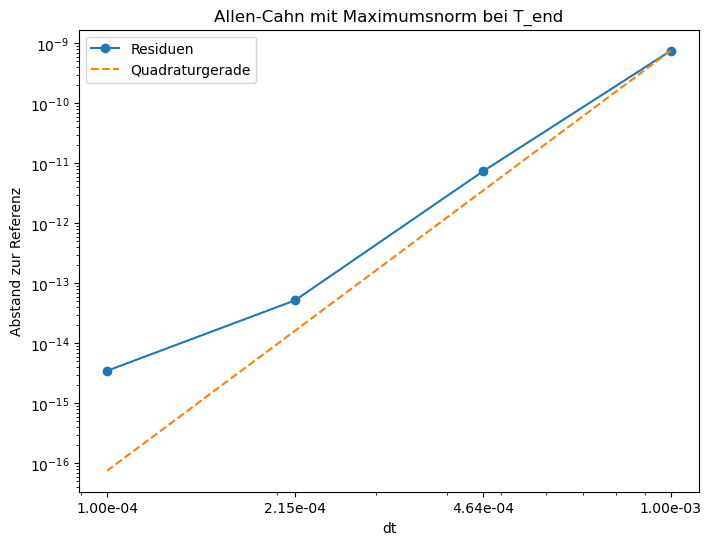

In [28]:
fig = plt.figure(figsize=(8, 6))
conv_line = cp.power(dts_allen, 7) * norms_allen[0]/np.power(dts_allen[0], 7)
plt.plot(dts_allen.get(), norms_allen.get(), marker = "o", label="Residuen")
plt.plot(dts_allen.get(), conv_line.get(), linestyle="dashed", label="Quadraturgerade")
plt.xscale("log", base = 10)
plt.yscale("log", base = 10)
#plt.ylim(1E-15, 1E-8)
plt.xlabel("dt")
plt.ylabel("Abstand zur Referenz")
plt.xticks(dts_allen.get(), labels=["{:.2e}".format(dt) for dt in dts_allen.get()])
plt.legend()
plt.title("Allen-Cahn mit Maximumsnorm bei T_end")
plt.savefig(image_path("allencahn_maximumsnorm_newsdc.png"))
plt.show()

In [20]:
data = cp.empty((5, 4))
dt = 5E-4
for maxIter in range(1, len(data)+1):
    print(maxIter)
    gmres_snf = nonlinear_sdc_cahn(dt=dt, num_nodes =3, outer_abs_tol=1E-14, inner_abs_tol=1E-14, n_max=maxIter, nvars=(64, 64))[5]
    gmres_nsf = nonlinear_cahn(dt=dt, num_nodes=3, outer_abs_tol = 1E-14, inner_abs_tol=1E-14, k_max=maxIter, nvars=(64, 64))[5]
    gmres_snf_const = nonlinear_sdc_cahn(dt=dt, num_nodes =3, outer_abs_tol=1E-14, inner_abs_tol=1E-14, n_max=maxIter, nvars=(64, 64), const_inner_iteration=True)[5]
    gmres_nsf_const = nonlinear_cahn(dt=dt, num_nodes=3, outer_abs_tol = 1E-14, inner_abs_tol=1E-14, k_max=maxIter, nvars=(64, 64), const_inner_iteration=True)[5]

    data[maxIter-1] = cp.asarray([gmres_snf, gmres_nsf, gmres_snf_const, gmres_nsf_const])

1
2
3
4
5


In [21]:
data

array([[ 306.,  306.,  306.,  306.],
       [ 610.,  341.,  610.,  356.],
       [ 735.,  365.,  915.,  366.],
       [ 775.,  386., 1220.,  408.],
       [ 776.,  409., 1525.,  410.]])

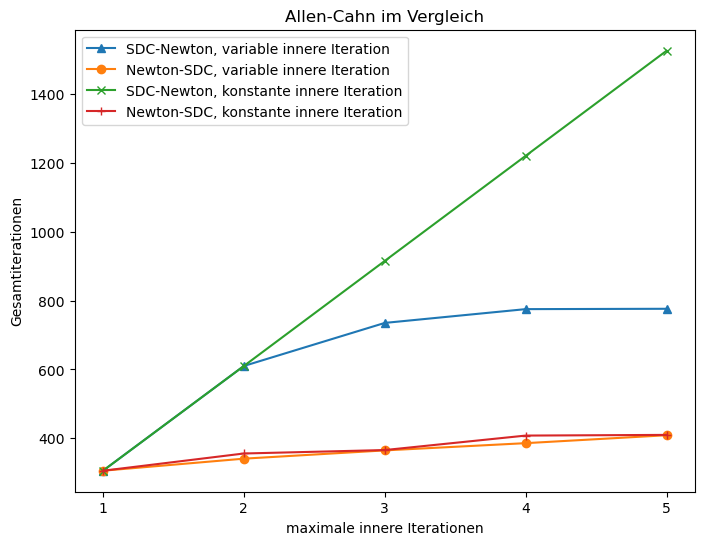

In [22]:
plt.figure(figsize=(8, 6))
plt.title("Allen-Cahn im Vergleich (GMRES)")
axis = np.arange(1, 6)
plt.plot(axis, data[::, 0].get(), label="SDC-Newton, variable innere Iteration", marker="^")
plt.plot(axis, data[::, 1].get(), label="Newton-SDC, variable innere Iteration", marker="o")
plt.plot(axis, data[::, 2].get(), label="SDC-Newton, konstante innere Iteration", marker="x")
plt.plot(axis, data[::, 3].get(), label="Newton-SDC, konstante innere Iteration", marker="+")
plt.xticks(axis, labels =["{}".format(dt) for dt in axis])
plt.xlabel("maximale innere Iterationen")
plt.ylabel("Gesamt-GMRES-Iterationen")
plt.legend()
plt.savefig(image_path("allencahnvergleich.png"))
plt.show()

In [16]:
columns = ["method", "problem","tol", "dt", "quad_nodes", "nvars", "new_max", "sdc_sum", "new_sum", "norm"]
table = pd.DataFrame(columns=columns)

for dt in [0.0005, 0.00005]:
    for quadn in [2, 3, 4, 5]:
        for nvars in [(64, 64), (128, 128), (256, 256)]:
            for niter in [1, 2, 3, 5, 10, 20]:
                print((dt, quadn, nvars, niter))
                u1, t1, prob, ksum, nsum, gmres_sum, conv_buffer = nonlinear_sdc_cahn(dt=dt, num_nodes = quadn, nvars=nvars, n_max=niter, outer_abs_tol = 1E-12, inner_abs_tol=1E-12)
                max_norm = cp.linalg.norm(u1[-1]-cp.asarray(prob.u_exact(t1[-1]).flatten()), np.inf)
                row = ["sdc_newton", "allencahn", 1E-12, dt, quadn, nvars, niter, ksum, nsum, max_norm.get()]
                table.loc[len(table.index)] = row

table

(0.0005, 2, (64, 64), 1)
(0.0005, 2, (64, 64), 2)
(0.0005, 2, (64, 64), 3)
(0.0005, 2, (64, 64), 5)
(0.0005, 2, (64, 64), 10)
(0.0005, 2, (64, 64), 20)
(0.0005, 2, (128, 128), 1)
(0.0005, 2, (128, 128), 2)
(0.0005, 2, (128, 128), 3)
(0.0005, 2, (128, 128), 5)
(0.0005, 2, (128, 128), 10)
(0.0005, 2, (128, 128), 20)
(0.0005, 2, (256, 256), 1)
(0.0005, 2, (256, 256), 2)
(0.0005, 2, (256, 256), 3)
(0.0005, 2, (256, 256), 5)
(0.0005, 2, (256, 256), 10)
(0.0005, 2, (256, 256), 20)
(0.0005, 3, (64, 64), 1)
(0.0005, 3, (64, 64), 2)
(0.0005, 3, (64, 64), 3)
(0.0005, 3, (64, 64), 5)
(0.0005, 3, (64, 64), 10)
(0.0005, 3, (64, 64), 20)
(0.0005, 3, (128, 128), 1)
(0.0005, 3, (128, 128), 2)
(0.0005, 3, (128, 128), 3)
(0.0005, 3, (128, 128), 5)
(0.0005, 3, (128, 128), 10)
(0.0005, 3, (128, 128), 20)
(0.0005, 3, (256, 256), 1)
(0.0005, 3, (256, 256), 2)
(0.0005, 3, (256, 256), 3)
(0.0005, 3, (256, 256), 5)
(0.0005, 3, (256, 256), 10)
(0.0005, 3, (256, 256), 20)
(0.0005, 4, (64, 64), 1)
(0.0005, 4, (64

,method,problem,tol,dt,quad_nodes,nvars,new_max,sdc_sum,new_sum,norm
0,sdc_newton,allencahn,1.000000e-12,0.00050,2,"(64, 64)",1,207,207,2.2793413507748994e-06
1,sdc_newton,allencahn,1.000000e-12,0.00050,2,"(64, 64)",2,205,410,2.2793417274735717e-06
2,sdc_newton,allencahn,1.000000e-12,0.00050,2,"(64, 64)",3,205,492,2.2793417259192594e-06
3,sdc_newton,allencahn,1.000000e-12,0.00050,2,"(64, 64)",5,205,514,2.2793417259192594e-06
4,sdc_newton,allencahn,1.000000e-12,0.00050,2,"(64, 64)",10,205,515,2.2793417259192594e-06
...,...,...,...,...,...,...,...,...,...,...
139,sdc_newton,allencahn,1.000000e-12,0.00005,5,"(256, 256)",2,1052,2104,2.4666380049609415e-12
140,sdc_newton,allencahn,1.000000e-12,0.00005,5,"(256, 256)",3,1052,2462,2.4665824938097103e-12
141,sdc_newton,allencahn,1.000000e-12,0.00005,5,"(256, 256)",5,1052,2463,2.4665824938097103e-12
142,sdc_newton,allencahn,1.000000e-12,0.00005,5,"(256, 256)",10,1052,2463,2.4665824938097103e-12


In [17]:
table.to_csv(table_path("sdcnew_allencahn_table.csv"))